# Previsione dell'affidabilità creditizia per il rilascio della carta di credito

Sei stato assunto dalla Pro National Bank come data scientist, e il tuo primo incarico consiste nel realizzare un modello in grado di stimare l'affidabilità creditizia dei clienti, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito.

## Colonne del dataset
- Colonne del dataset
- ID: numero identificativo del cliente
- CODE_GENDER: sesso del cliente
- FLAGOWNCAR: indicatore del possesso di un'automobile
- FLAGOWNREALTY: indicatore del possesso di una casa
- CNT_CHILDREN: numero di figli
- AMTINCOMETOTAL: reddito annuale
- NAMEINCOMETYPE: tipo di reddito
- NAMEEDUCATIONTYPE: livello di educazione
- NAMEFAMILYSTATUS: stato civile
- NAMEHOUSINGTYPE: tipo di abitazione
- DAYS_BIRTH: numero di giorni trascorsi dalla nascita
- DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)
- FLAG_MOBIL: indicatore della presenza di un numero di cellulare
- FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro
- FLAG_PHONE: indicatore della presenza di un numero di telefono
- FLAG_EMAIL: indicatore della presenza di un indirizzo email
- OCCUPATION_TYPE: tipo di occupazione
- CNTFAMMEMBERS: numero di familiari
- TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità creditizia (pagamento costante delle rate), 0 altrimenti.

## Obiettivo

Devi realizzare un modello che preveda il target dato, ovvero la variabile TARGET che indica se il cliente ha una buona affidabilità creditizia.

## Punto bonus

Se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione. Questo significa che il tuo modello deve fornire delle indicazioni facilmente interpretabili.

# Librerie utilizzate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from imblearn.under_sampling import RandomUnderSampler

# Esplorazione del dataset

In [3]:
!wget https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv

--2025-07-15 16:18:02--  https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_scoring.csv
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.206.118, 3.5.205.182
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.206.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46985859 (45M) [text/csv]
Saving to: ‘credit_scoring.csv’

credit_scoring.csv  100%[===================>]  44.81M  16.1MB/s    in 2.8s    

2025-07-15 16:18:05 (16.1 MB/s) - ‘credit_scoring.csv’ saved [46985859/46985859]



In [20]:
df = pd.read_csv("credit_scoring.csv")

df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,-11778.0,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,-11777.0,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,-21471.0,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-18489.0,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19093.0,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

In [6]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET
count,3.384270e+05,338427.000000,3.384270e+05,338426.000000,338426.000000,338426.0,338426.000000,338426.000000,338426.000000,338426.000000,338427.000000
mean,5.821200e+06,0.428934,1.876685e+05,-15998.212897,60234.533869,1.0,0.211379,0.293302,0.105181,2.197228,0.087824
std,4.517704e+05,0.727990,1.107863e+05,4193.088539,138522.923248,0.0,0.408287,0.455276,0.306787,0.899570,0.283039
min,5.008804e+06,0.000000,2.554898e+04,-26636.000000,-17973.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.439602e+06,0.000000,1.212299e+05,-19467.000000,-3116.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.878907e+06,0.000000,1.628553e+05,-15623.000000,-1483.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,6.140206e+06,1.000000,2.252082e+05,-12516.250000,-378.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,6.841875e+06,19.000000,7.071016e+06,-7566.000000,396498.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000


Con la funzione describe otteniamo molte informazioni utili:
* Innanzitutto possiamo vedere una media di circa 0,43 figli per persona. Questo ci dice che su circa 340.000 persone, ci deve essere una preponderante presenza di persone senza figli. Si vedrà comunque più avanti nella sezione dedicata
* Il reddito totale copre un range molto ampio, che va da 25k a poco più di 7 milioni. Evidentemente è una variabile con una coda molto lunga verso destra, ma vista la media molto vicina al 75mo percentile, possiamo dedurre che la distribuzione sia tutta concentrata verso sinistra
* La variabile DAYS_BIRTH, dividendola per 365 giorni l'anno, mostra un range di età che va dai quasi 73 anni (valore minimo essendo in negativo) ai 20, con una media attorno ai 43


In [7]:
print(f"Età minima:{-(df['DAYS_BIRTH'].min()/365): .2f}"),
print(f"Età massima:{-(df['DAYS_BIRTH'].max()/365): .2f}"),
print(f"Età media:{-(df['DAYS_BIRTH'].mean()/365): .2f}")

Età minima: 72.98
Età massima: 20.73
Età media: 43.83


* La variabile DAYS_EMPLOYED invece presenta una forte anomalia sui valori positivi, che indicano il tempo di disoccupazione trascorso. In particolare il valore massimo è di 396498 giorni, corrispondenti a più di 1000 anni. Chiaramente sarà oggetto di indagine più approfondita in seguito

In [8]:
print(f"Valore massimo di anni di disoccupazione: {df['DAYS_EMPLOYED'].max()/365: .2f}")

Valore massimo di anni di disoccupazione:  1086.30


* L'ultima variabile degna di nota è il conteggio dei membri della famiglia che va da un minimo di 1 (nessun figlio) a un massimo di 20. Facendo una verifica sottraendo i valori della variabile CNT_FAM_MEMBERS alla variabile CNT_CHILDREN non risultano anomalie, dal momento che gli unici due valori di questa differenza sono 1 (1 solo genitore) o 2 (2 genitori)

In [9]:
(df["CNT_FAM_MEMBERS"]-df["CNT_CHILDREN"]).value_counts()

,count
2.0,260010
1.0,78416


L'ultimo controllo di alto livello, prima di procedere con le ispezioni di dettaglio, è quello sui valori vuoti e un dato spicca su tutti: la variabile OCCUPATION_TYPE che presenta 103342 valori vuoti, corrispondenti a circa il 31% delle osservazioni.

Senza dubbio dovrà essere approfondito anche questo aspetto per capire come trattare la variabile in fase di data pre-processing.

In [10]:
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


In [11]:
df.isna().sum()["OCCUPATION_TYPE"]/df.shape[0]

np.float64(0.3053597969429153)

* Infine, la variabile TARGET che, come era lecito aspettarsi, non risulta bilanciata nel dataset e di questo se ne dovrà tenere conto in fase di addestramento del modello

In [12]:
df["TARGET"].value_counts()/df["TARGET"].value_counts().sum()

,count
TARGET,
0,0.912176
1,0.087824


## Conversione della variabile DAYS_BIRTH

Per una maggiore fruibilità nella lettura della variabile, la si converte in anni e in valore positivo, dal momento che ora si presenta con valori negativi e in giorni.

In [21]:
df["DAYS_BIRTH"] = -(df["DAYS_BIRTH"]/365)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,32.268493,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,32.265753,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338422,6392175,F,N,Y,0,158517.14,Pensioner,Secondary / secondary special,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338423,6392177,F,N,Y,0,156354.84,Pensioner,Secondary / secondary special,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338424,6392178,F,N,Y,0,159019.43,Pensioner,Secondary / secondary special,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338425,6392179,F,N,Y,0,162723.53,Pensioner,Secondary / secondary special,Married,House / apartment,65.178082,350457.0,1.0,0.0,0.0,0.0,NaN,2.0,0


In [23]:
df.rename(columns={"DAYS_BIRTH":"AGE"}, inplace=True)
df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,32.268493,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,32.265753,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338422,6392175,F,N,Y,0,158517.14,Pensioner,Secondary / secondary special,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338423,6392177,F,N,Y,0,156354.84,Pensioner,Secondary / secondary special,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338424,6392178,F,N,Y,0,159019.43,Pensioner,Secondary / secondary special,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,NaN,2.0,0
338425,6392179,F,N,Y,0,162723.53,Pensioner,Secondary / secondary special,Married,House / apartment,65.178082,350457.0,1.0,0.0,0.0,0.0,NaN,2.0,0


## I Figli

Cerchiamo di capire come sia distribuita la variabile CNT_CHILDREN e che rapporto ci sia con la variabile TARGET

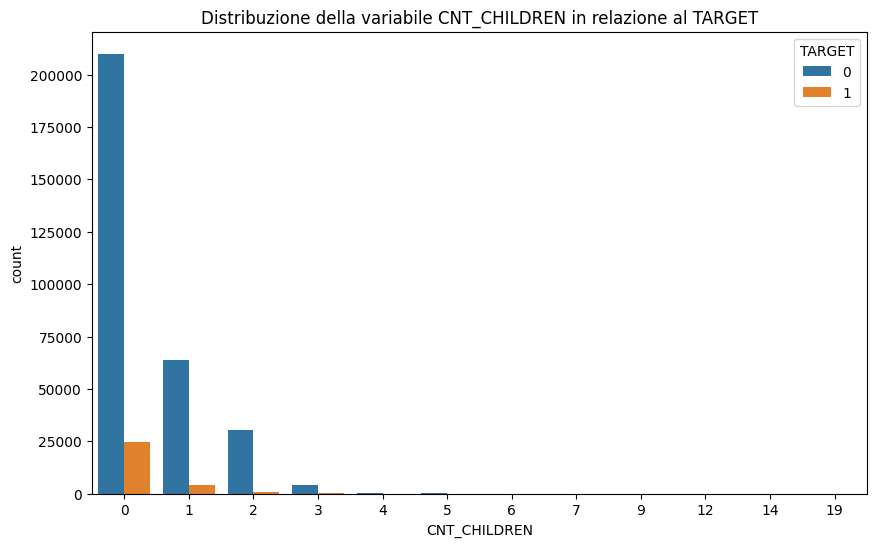

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = "CNT_CHILDREN", hue = "TARGET")
plt.title("Distribuzione della variabile CNT_CHILDREN in relazione al TARGET")
plt.show()

Come si era anticipato, la distribuzione è fortemente sbilanciata verso sinistra con una coda lunga verso destra. La maggior parte delle conversioni si è verificata su chi non ha figli, ma questo può anche essere un effetto della maggiore presenza di questa categoria.

## Il genere

Verifichiamo se ci sia una correlazione tra l'affidabilità creditizia e il genere. Partiamo dal capire la distribuzione della variabile e possiamo vedere che le donne siano il doppio degli uomini nel dataset.

In [13]:
df["CODE_GENDER"].value_counts()

,count
CODE_GENDER,
F,227916
M,110511


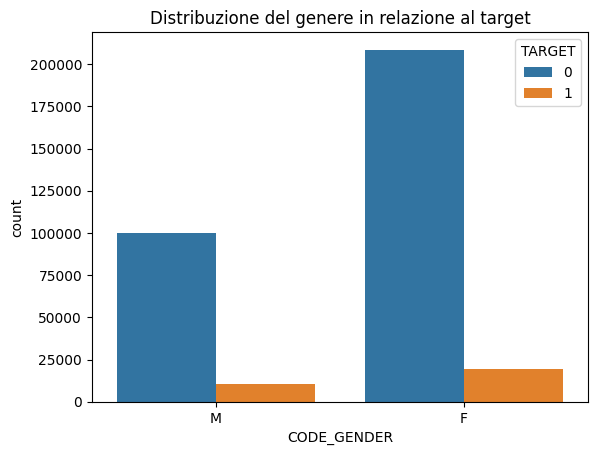

In [14]:
sns.countplot(data = df, x = "CODE_GENDER", hue="TARGET")
plt.title("Distribuzione del genere in relazione al target")
plt.show()

Di nuovo, sembra che le donne abbiano una maggiore affidabilità creditizia, ma può essere un effetto dovuto unicamente alla maggiore presenza di donne nel dataset. Effettivamente, come si può vedere dal calcolo sottostante, non c'è differenza sostanziale, nel target, tra i generi.

In [15]:
pd.crosstab(df["TARGET"], df["CODE_GENDER"])/pd.crosstab(df["TARGET"], df["CODE_GENDER"]).sum()

CODE_GENDER,F,M
TARGET,,
0,0.915109,0.906127
1,0.084891,0.093873


Vediamo infine se sia presente una qualche differenza sostanziosa nei redditi tra i generi, per capire se possa un target essere più affidabile dell'altro.

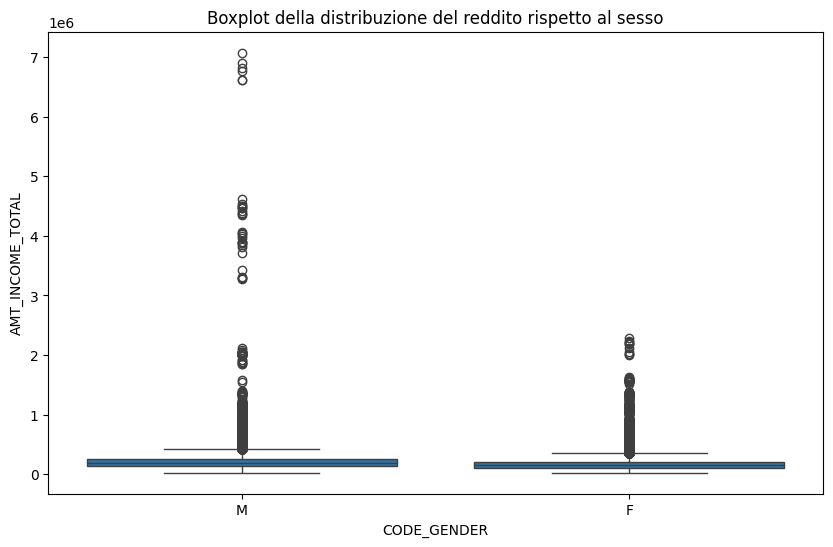

In [88]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="CODE_GENDER", y="AMT_INCOME_TOTAL")
plt.title("Boxplot della distribuzione del reddito rispetto al sesso")
plt.show()

Come immaginato a inizio capitolo, la variabile AMT_INCOME_TOTAL è talmente ampia su range di valori molto distanti, che rende il boxplot poco leggibile. Procediamo dunque filtrando via i valori chiaramente outliars

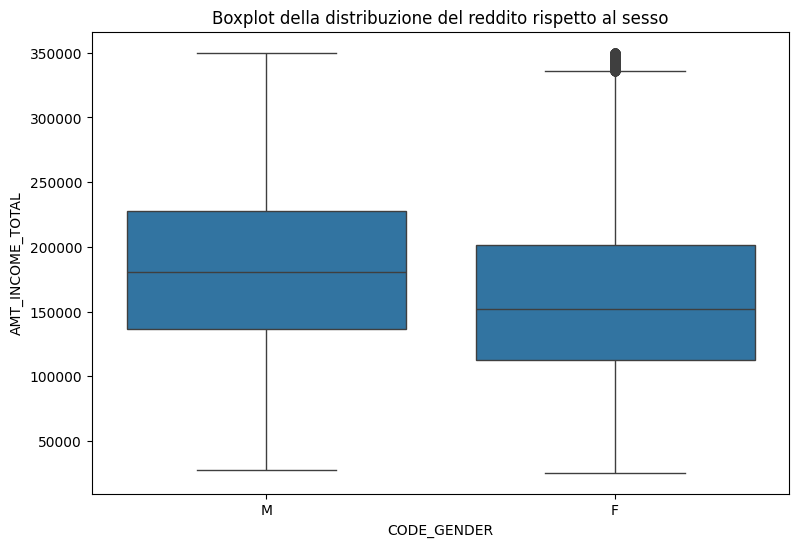

In [89]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df[df["AMT_INCOME_TOTAL"] < 350000],
            x="CODE_GENDER",
            y="AMT_INCOME_TOTAL")
plt.title("Boxplot della distribuzione del reddito rispetto al sesso")
plt.show()

Possiamo vedere che esiste una differenza di reddito, all'interno del dataset, tra uomo e donna, ma è una differenza che non impatta ai fini dell'affidabilità creditizia per l'ottenimento di una carta di credito.

## Il reddito totale

Dal grafico sottostante troviamo conferma del fatto che la distribuzione della variabile AMT_INCOME_TOTAL sia effettivamente addensata sulla sinistra, ma con una coda destra molto lunga

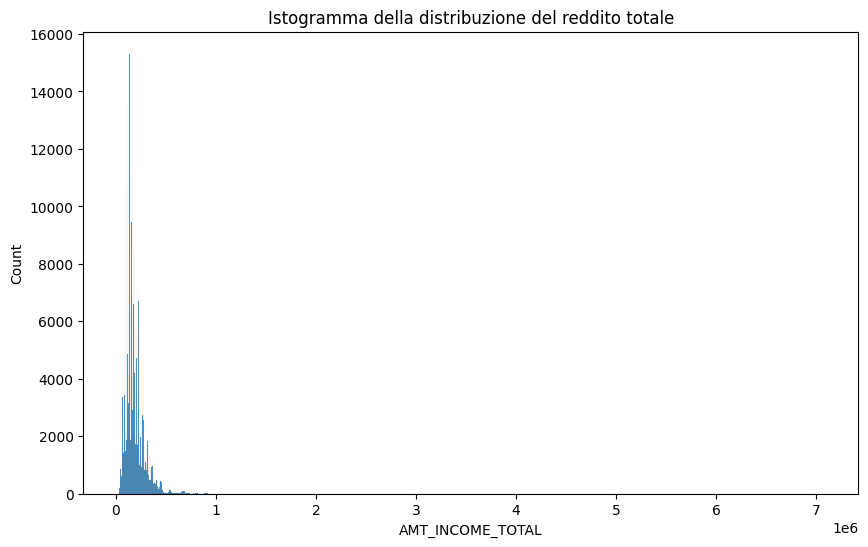

In [91]:
plt.figure(figsize=(10,6))
sns.histplot(data = df, x = "AMT_INCOME_TOTAL")
plt.title("Istogramma della distribuzione del reddito totale")
plt.show()

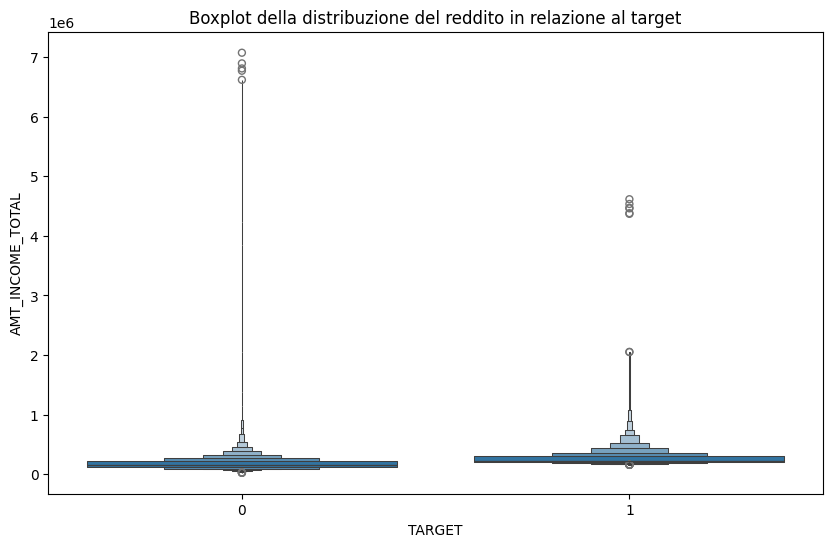

In [92]:
plt.figure(figsize=(10,6))
sns.boxenplot(data= df, x="TARGET", y = "AMT_INCOME_TOTAL")
plt.title("Boxplot della distribuzione del reddito in relazione al target")
plt.show()

Dal momento che la maggior parte dei dati sembra essere contenuta entro il milione, proviamo a filtrare il dataset così da avere migliore visione della distribuzione

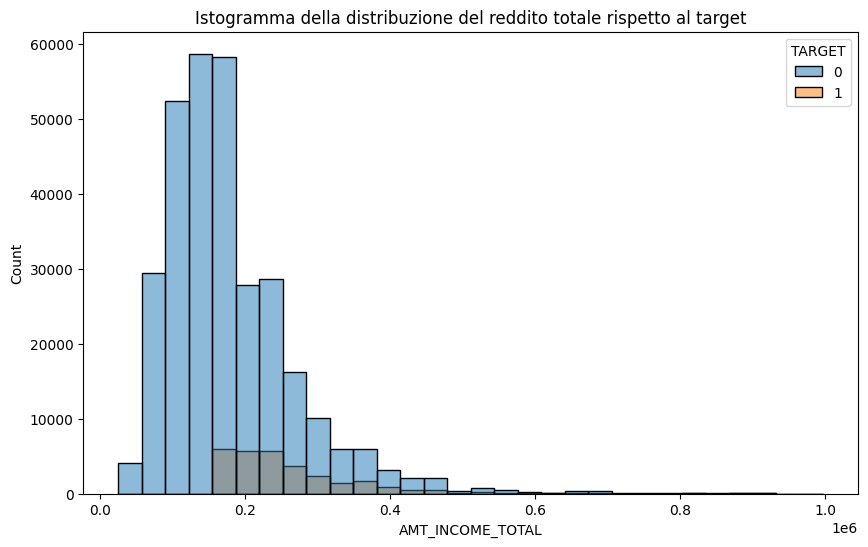

In [93]:
plt.figure(figsize=(10,6))
sns.histplot(data = df[df["AMT_INCOME_TOTAL"] < 1000000], x = "AMT_INCOME_TOTAL", bins = 30, hue = "TARGET")
plt.title("Istogramma della distribuzione del reddito totale rispetto al target")
plt.show()

Dal grafico possiamo inoltre vedere che risulta essere presente una sorta di soglia al di sotto della quale non sono stati mai considerati affidabili, all'incirca al di sotto dei 185k.

Andiamo a restringere ancora di più l'intervallo di valori filtrati per il reddito totale così da tagliare via molti outliars e avere una migliore visione del boxplot che lo mette in relazione al target

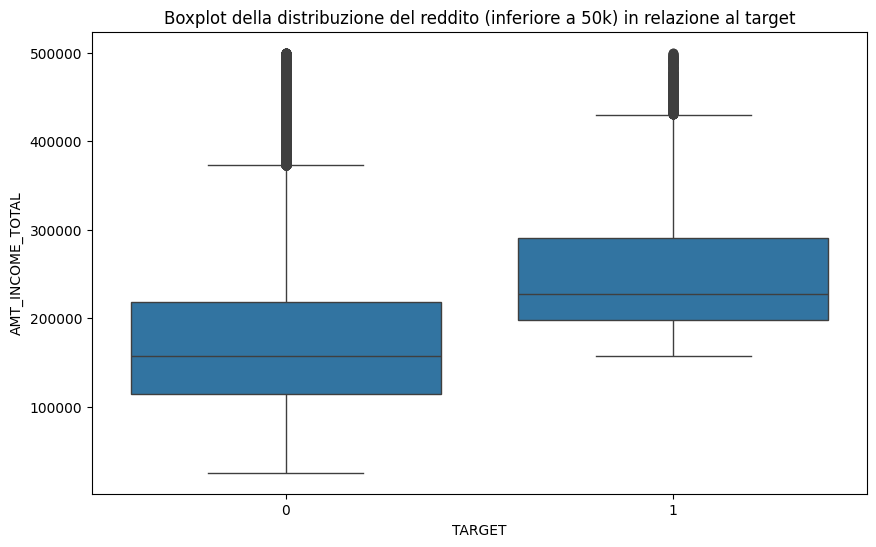

In [95]:
tgt_income_filtered = df[df["AMT_INCOME_TOTAL"] < 500000]
plt.figure(figsize=(10,6))
sns.boxplot(data = tgt_income_filtered, x="TARGET", y = "AMT_INCOME_TOTAL")
plt.title("Boxplot della distribuzione del reddito (inferiore a 50k) in relazione al target")
plt.show()

Da questo grafico risulta ancora più evidente come l'affidabilità creditizia sia stata assegnata laddove i redditi fossero comunque più alti, circa dai 200k in su. Il valore è più alto rispetto all'istogramma perchè qui ci stiamo concentrando su un sottoinsieme dei valori del reddito.

Molto interessante invece il fatto che, per redditi superiori al milione, ci siano molti più outliars su alti valori di reddito, proprio dove l'affidabilità creditizia non è stata assegnata.

Questo potrebbe indicare che un reddito alto, non è comunque un indicatore universale di solvibilità.

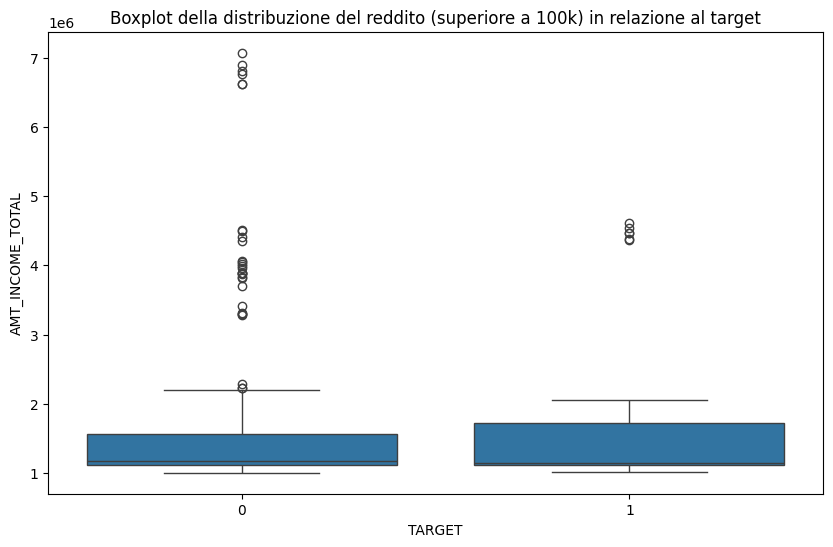

In [96]:
tgt_income_filtered = df[df["AMT_INCOME_TOTAL"] > 1000000]
plt.figure(figsize=(10,6))
sns.boxplot(data = tgt_income_filtered, x="TARGET", y = "AMT_INCOME_TOTAL")
plt.title("Boxplot della distribuzione del reddito (superiore a 100k) in relazione al target")
plt.show()

## Anzianità

Verifichiamo se ci sia una qualche relazione tra l'affidabilità creditizia e l'età della persona. In effetti il boxplot sotto riportato mostra chiaramente che sono stati ritenuti affidabili i clienti più anziani.

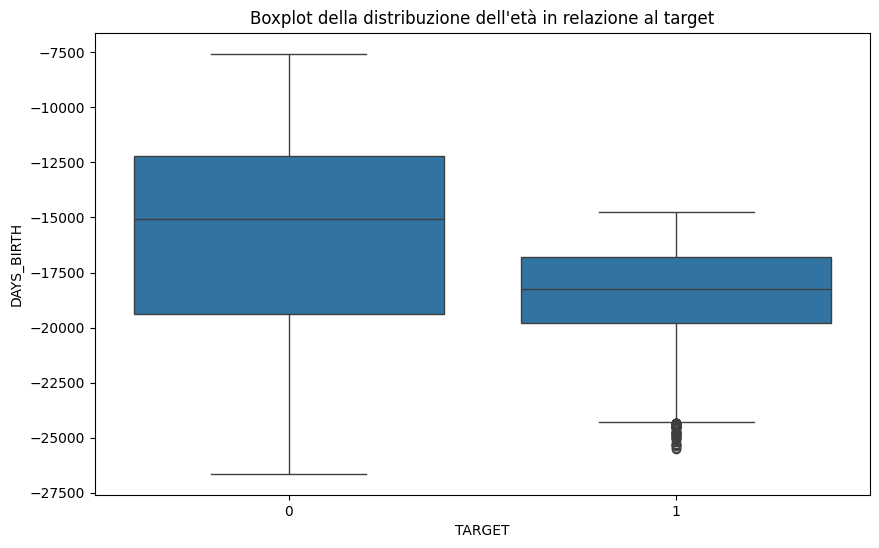

In [97]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = "TARGET", y = "DAYS_BIRTH")
plt.title("Boxplot della distribuzione dell'età in relazione al target")
plt.show()

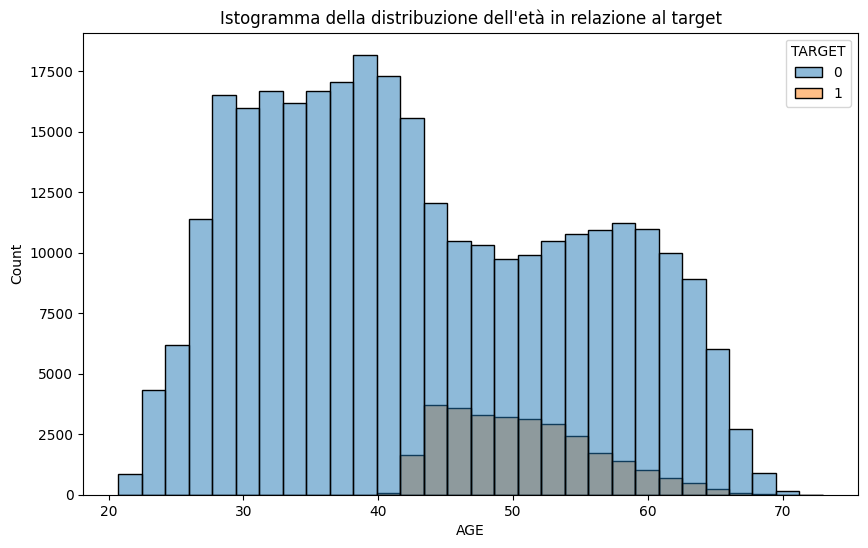

In [25]:
plt.figure(figsize=(10,6))
sns.histplot(data = df, x = "AGE", hue = "TARGET", bins = 30)
plt.title("Istogramma della distribuzione dell'età in relazione al target")
plt.show()

Una possibile ipotesi del perchè non venga concessa l'affidabilità creditizia ai più giovani, potrebbe essere dovuta al fatto che comunque un ragazzo potrebbe avere una stabilità economica non paragonabile a quella di un adulto e occupi una fascia di reddito inferiore.

Vediamo che dai 40 anni in su si inizia a vedere l'affidabilità creditizia. Proviamo ad indagare maggiormente e vediamo che relazione ci sia tra reddito ed età.

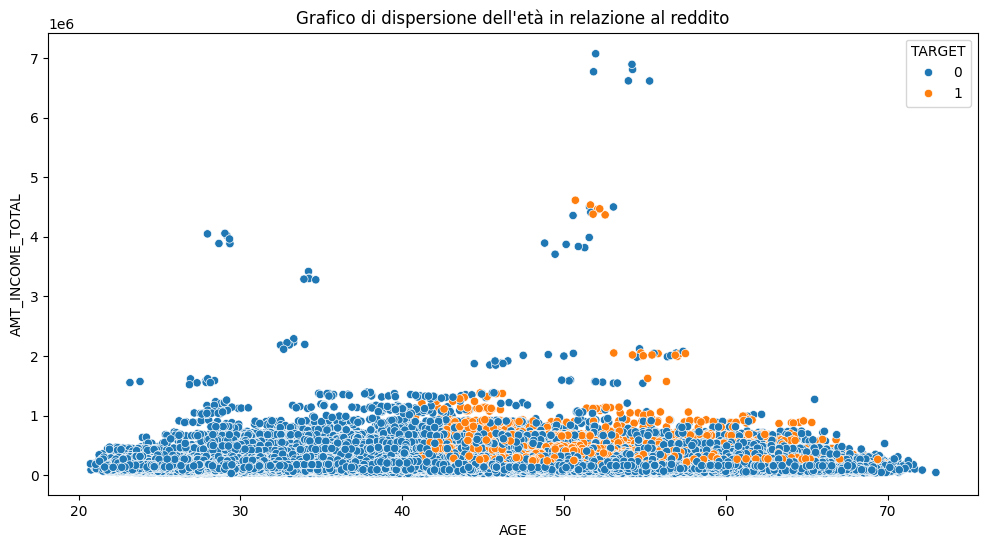

In [27]:
plt.figure(figsize=(12,6))
sns.scatterplot(data = df, x="AGE", y="AMT_INCOME_TOTAL", hue="TARGET")
plt.title("Grafico di dispersione dell'età in relazione al reddito")
plt.show()

Dal grafico sopra riportato si vede chiaramente non c'è grande differenza, in termini di reddito, tra la destra e la sinistra dei 40 anni. Quindi, nuovamente, il reddito non sembra essere, considerato da solo, una discriminante.

Proviamo a vedere allora che relazione ci sia tra età e tipo di occupazione

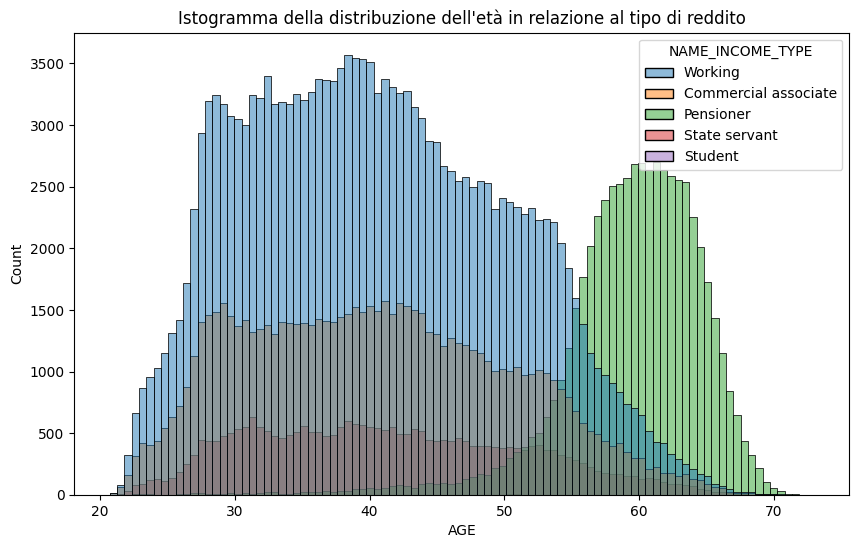

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(data = df, x = "AGE", hue = "NAME_INCOME_TYPE")
plt.title("Istogramma della distribuzione dell'età in relazione al tipo di reddito")
plt.show()

Anche il grafico sopra riportato non evidenzia, in termini di fonte di reddito, delle differenze sostanziali tra prima e dopo i 40 anni. Sembra quasi a questo punto una soglia di età pre impostata dall'istituto di credito.

Anche il boxplot sottostante, che mette in relazione le fonti di reddito rispetto all'età, conferma la netta separazione tra la concessione e non dell'affidabilità creditizia, indipendentemente dalla fonte di reddito e sempre allineata da una certa età in avanti.

Degno di nota che la categoria dei pensionati non abbia mai ricevuto l'affidabilità creditizia.

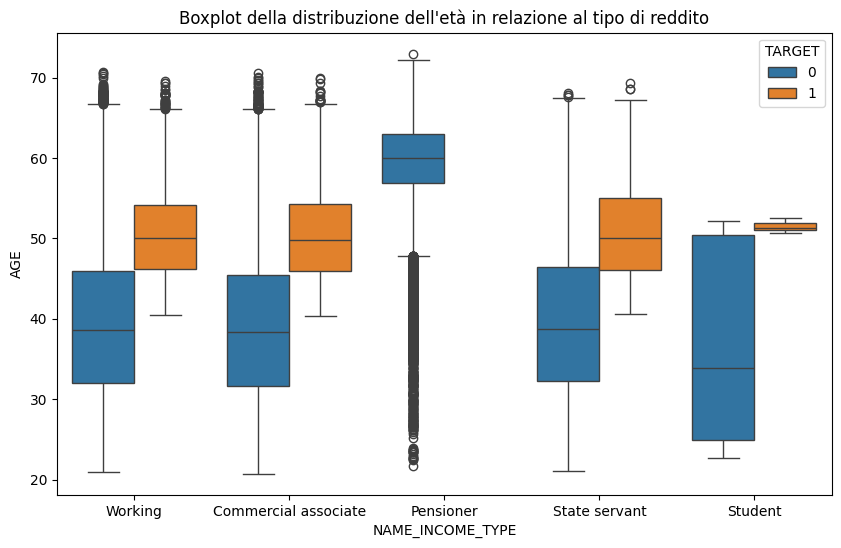

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df, x = "NAME_INCOME_TYPE", y = "AGE", hue = "TARGET")
plt.title("Boxplot della distribuzione dell'età in relazione al tipo di reddito")
plt.show()

## Figli e famiglie

Cerchiamo di capire se esista una qualche relazione tra la variabile target e la composizione familiare

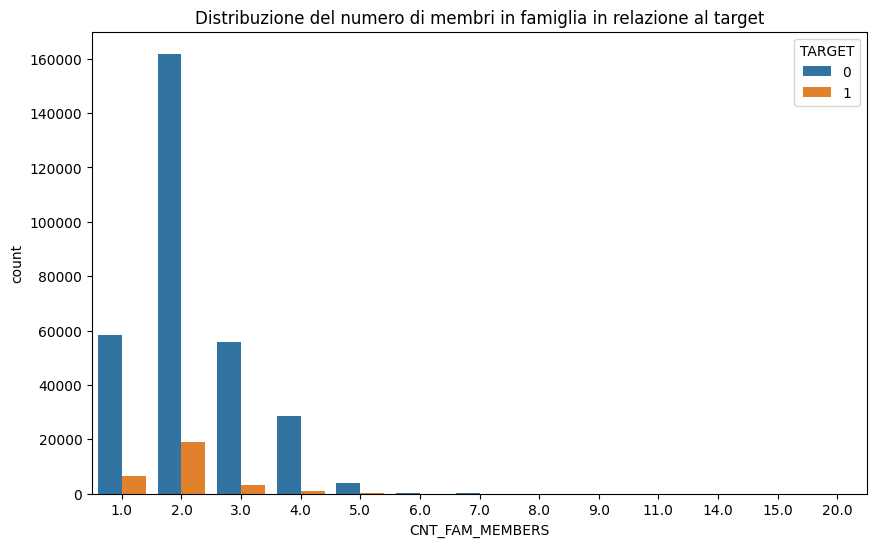

In [102]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = df["CNT_FAM_MEMBERS"], hue = df["TARGET"])
plt.title("Distribuzione del numero di membri in famiglia in relazione al target")
plt.show()

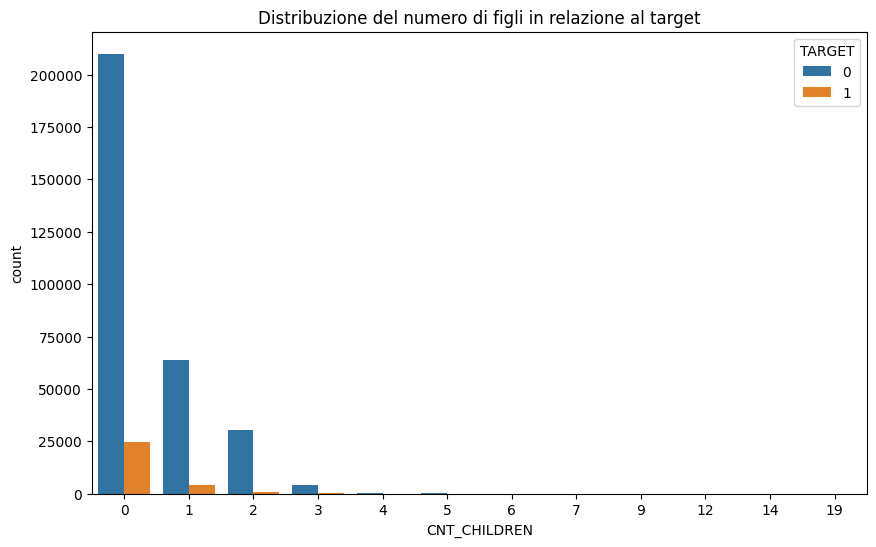

In [103]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = df["CNT_CHILDREN"], hue = df["TARGET"])
plt.title("Distribuzione del numero di figli in relazione al target")
plt.show()

Dal momento che le famiglie nel dataset sono per la grande maggioranza comprese da 2 individui (2 adulti o 1 adulto e 1 figlio), non si possono trarre conclusioni significative su un possibile legame con la variabile target perchè è ovviamente preponderante su queste classi essendo le più numerose di gran lunga.

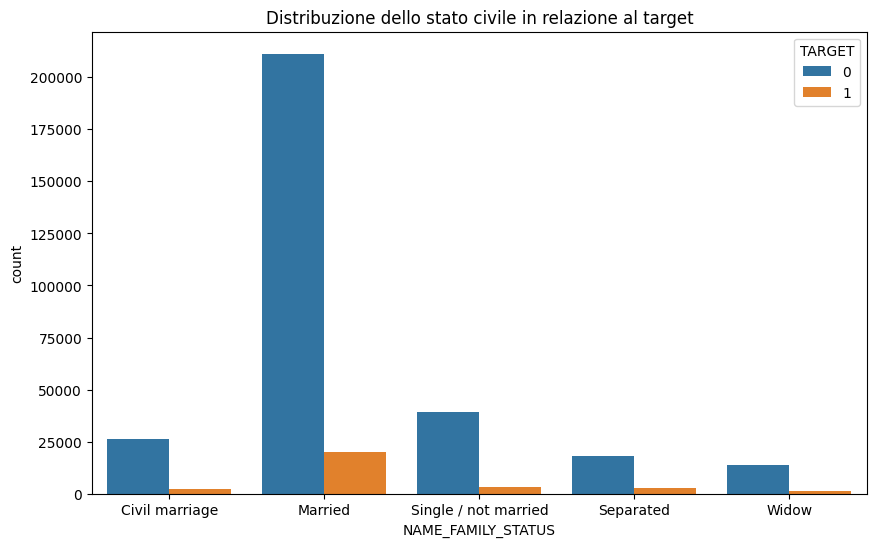

In [104]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = "NAME_FAMILY_STATUS", hue = "TARGET")
plt.title("Distribuzione dello stato civile in relazione al target")
plt.show()

Di nuovo, non sembra emergere alcuno schema particolare che colleghi l'affidabilità creditizia con lo stato di famiglia. L'unico commento evidente che si può fare è la presenza preponderante nel dataset di coppie sposate.

## Unità immobiliare

Vediamo, come fatto per le altre variabili, se emerga un qualche schema identificabile a occhio tra la variabile NAME_HOUSING_TYPE e TARGET

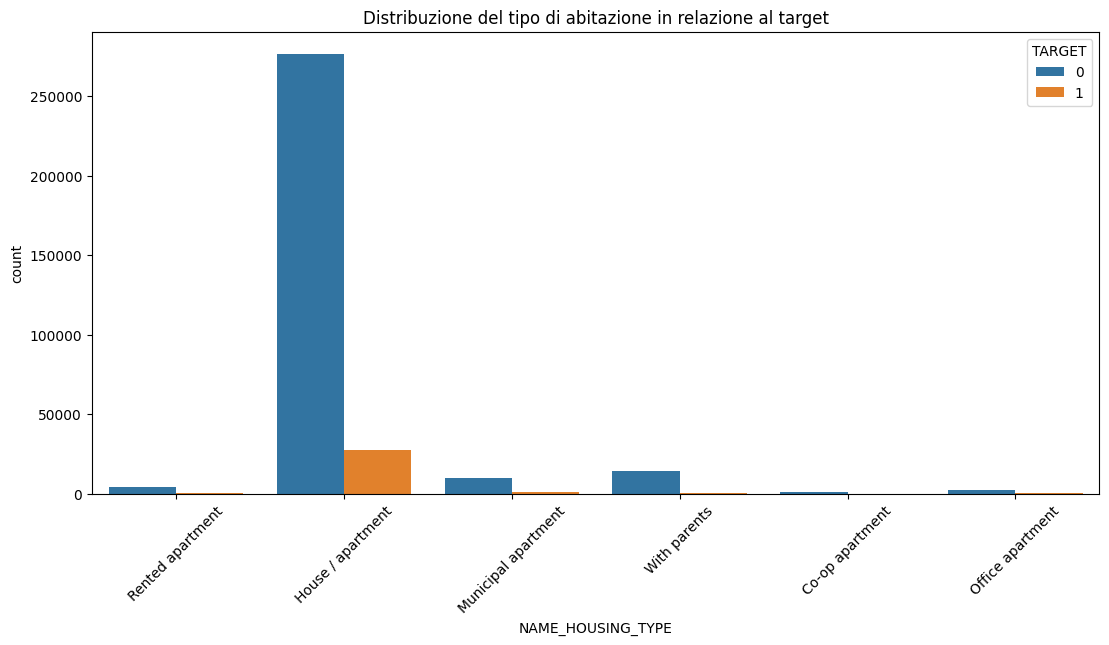

In [105]:
plt.figure(figsize=(13,6))
sns.countplot(data = df, x = "NAME_HOUSING_TYPE", hue = "TARGET")
plt.title("Distribuzione del tipo di abitazione in relazione al target")
plt.xticks(rotation=45)
plt.show()

Come per le altre variabili, c'è una moda, House/apartment, che stacca di molto il resto delle osservazioni e di conseguenza non consente di trarre alcuna conclusione, in maniera isolata, sul comportamento della variabile target.

## Anomalia sulla variabile DAYS_EMPLOYED > 0

Come visto nell'esplorazione iniziale del dataset, la variabile DAYS_EMPLOYED ha un valore massimo anomalo che corrisponde a più di 1000 anni.

In [32]:
df[df["DAYS_EMPLOYED"] > 0].describe()["DAYS_EMPLOYED"]

,DAYS_EMPLOYED
count,57841.000000
mean,365218.390052
std,7328.552325
min,334364.000000
25%,360291.000000
50%,365234.000000
75%,370199.000000
max,396498.000000


Il sospetto è che possa essere in realtà una variabile convenzionalmente impostata così alta per indicare altro.

Dal momento che, tendenzialmente, questi valori "convenzionali" sono impostati per non lasciare un campo che altrimenti resterebbe vuoto, si potrebbe andare a controllare il comportamento di questa variabile rispetto alla variabile "NAME_INCOME_TYPE". Dal momento che uno dei possibili valori di questa variabile indica i pensionati, avrebbe perfettamente senso che per questa categoria sia stato impossibile definire i giorni di disoccupazione.

In [33]:
df["NAME_INCOME_TYPE"].value_counts()

,count
NAME_INCOME_TYPE,
Working,174366
Commercial associate,78090
Pensioner,57841
State servant,28113
Student,17


In [34]:
df[df["DAYS_EMPLOYED"] > 0]["NAME_INCOME_TYPE"].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,57841


Nel dataset ci sono 57841 e sono tutti e soli loro ad avere dei valori della variabile DAYS_EMPLOYED positiva e altissima. Questo ci conferma che i valori positivi alti sono convenzionali e indicano una persona "indefinitamente disoccupata", dal momento che per un pensionato non si può dire per quanti giorni sarà disoccupato.

Ovviamente sarà cruciale, prima della fase di addestramento, standardizzare questi valori che si presentano su una scala molto diversa da quelli usuali.

## Fonti di reddito e tipo di occupazione

Andiamo a vedere come sono distribuite nel dataset queste variabili

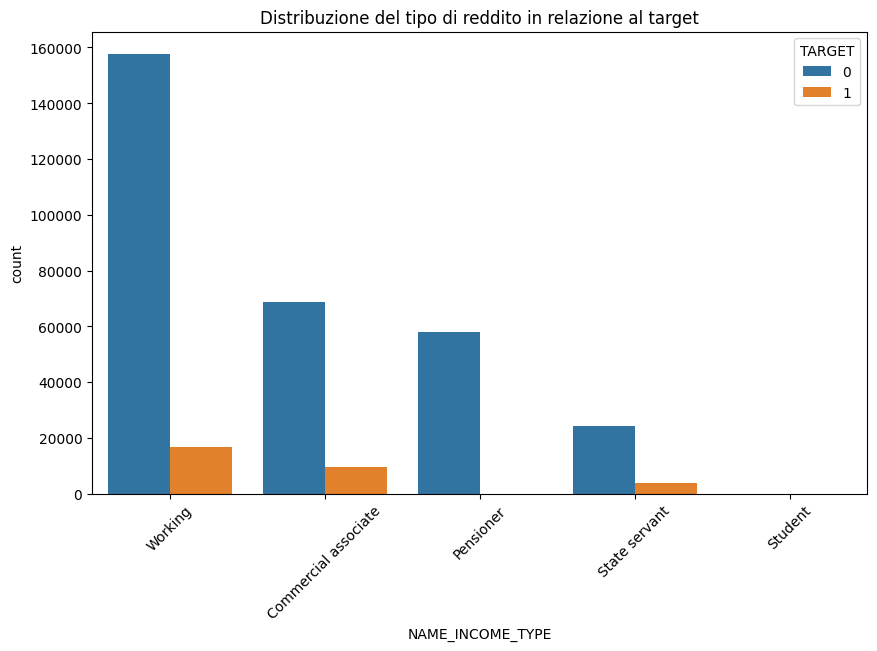

In [106]:
plt.figure(figsize=(10,6))
sns.countplot(data = df, x = "NAME_INCOME_TYPE", hue = "TARGET")
plt.xticks(rotation = 45)
plt.title("Distribuzione del tipo di reddito in relazione al target")
plt.show()

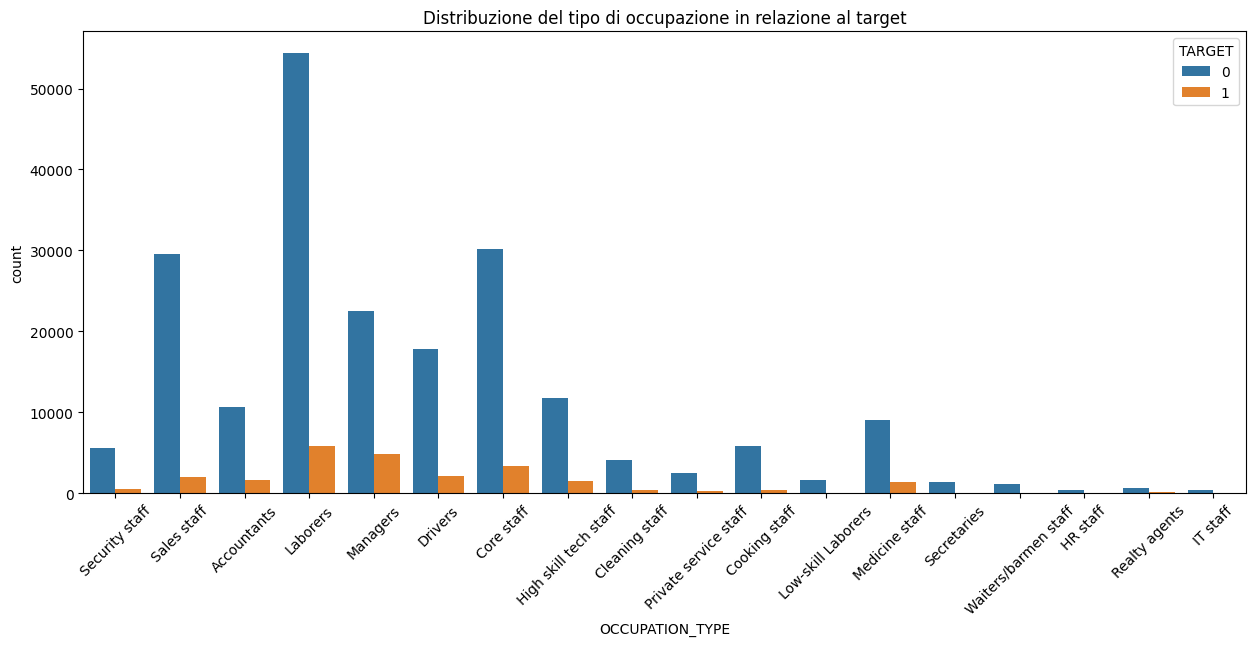

In [107]:
plt.figure(figsize=(15,6))
sns.countplot(data = df, x = "OCCUPATION_TYPE", hue = "TARGET")
plt.xticks(rotation = 45)
plt.title("Distribuzione del tipo di occupazione in relazione al target")
plt.show()

In [37]:
round(pd.crosstab(df["TARGET"], df["OCCUPATION_TYPE"])/pd.crosstab(df["TARGET"], df["OCCUPATION_TYPE"]).sum(), 2)

OCCUPATION_TYPE,Accountants,Cleaning staff,Cooking staff,Core staff,Drivers,HR staff,High skill tech staff,IT staff,Laborers,Low-skill Laborers,Managers,Medicine staff,Private service staff,Realty agents,Sales staff,Secretaries,Security staff,Waiters/barmen staff
TARGET,,,,,,,,,,,,,,,,,,
0,0.87,0.9,0.94,0.9,0.89,0.85,0.88,0.95,0.9,0.95,0.82,0.86,0.88,0.85,0.94,0.93,0.9,0.97
1,0.13,0.1,0.06,0.1,0.11,0.15,0.12,0.05,0.1,0.05,0.18,0.14,0.12,0.15,0.06,0.07,0.1,0.03


Working è ovviamente la classe più rappresentata nel dataset, con laborers il tipo principale di occupazione. Non emerge tuttavia alcuno schema particolare relativamente all'ambito professionale rispetto alla variabile target.

Permane il dato che non vede alcuna affidabilità creditizia associata ai pensionati.

## Livello di istruzione

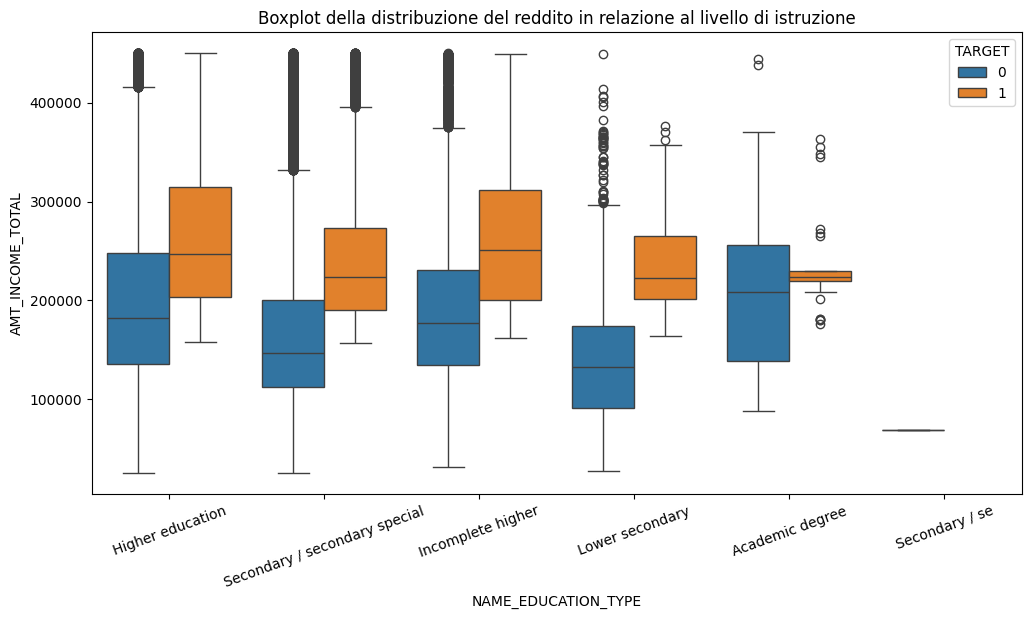

In [108]:
plt.figure(figsize=(12,6))
sns.boxplot(data = df[df["AMT_INCOME_TOTAL"] < 450000], x="NAME_EDUCATION_TYPE", y="AMT_INCOME_TOTAL", hue = "TARGET")
plt.xticks(rotation=20)
plt.title("Boxplot della distribuzione del reddito in relazione al livello di istruzione")
plt.show()

## Valori "NaN"

Infine indaghiamo il numero incredibile di valori NaN associati alla variabile OCCUPATION_TYPE. Si riassume qui di seguito l'osservazione anomala

In [30]:
df.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


Il sospetto è, dal momento che esiste una fonte di reddito da pensione, che non sia stato possibile per un pensionato identificare un valore per il tipo di occupazione.

Risulta lecito attendersi che in fase di compilazione del dataset, sia stato difficile identificare un valore con cui indicare l'occupazione di un pensionato e a differenza di DAYS_EMPLOYED in cui si è proceduto con un valore "convenzionale", qui si sia voluto lasciare il campo vuoto.

Proviamo vedendo le frequenze della variabile NAME_INCOME_TYPE che contiene il valore "Pensioner"

In [40]:
df["NAME_INCOME_TYPE"].value_counts().sort_index()

,count
NAME_INCOME_TYPE,
Commercial associate,78090
Pensioner,57841
State servant,28113
Student,17
Working,174366


I pensionati sono 57841, meno dei 102342 valori NaN di OCCUPATION_TYPE. Proviamo allora a effettuare il conteggio delle frequenze di NAME_INCOME_TYPE ma solo quando OCCUPATION_TYPE risulta NaN

In [41]:
df[df.isna()["OCCUPATION_TYPE"]]["NAME_INCOME_TYPE"].value_counts().sort_index()

,count
NAME_INCOME_TYPE,
Commercial associate,12927
Pensioner,57841
State servant,4785
Student,5
Working,27784


Ecco la conferma che cercavamo: tutti i pensionati hanno la variabile OCCUPATION_TYPE vuota. Esistono però anche altre fonti di reddito che non hanno l'occupazione specificata. Potrebbe trattarsi di dimenticanze o errori in fase di compilazione. Cerchiamo dunque di capire la percentuale di campi vuoti, per ogni fonte di reddito, rispetto al loro totale, in modo da capire come affrontare questi casi in sede di data processing.

In [42]:
df[df.isna()["OCCUPATION_TYPE"]]["NAME_INCOME_TYPE"].value_counts()/df["NAME_INCOME_TYPE"].value_counts().sort_index()

,count
NAME_INCOME_TYPE,
Commercial associate,0.165540
Pensioner,1.000000
State servant,0.170206
Student,0.294118
Working,0.159343


Questa è la situazione:
- Pensionati: ovviamente vale quanto detto in precedenza. Dal momento che è stata una scelta deliberata lasciare il campo vuoto, si procederà popolandolo con una stringa convenzionale in fase di data processing
- Commercial associate, State servant, Working: i valori vuoti sono tra il 16% e il 17% quindi possiamo procedere con l'eliminazione della riga
- Student: è quasi il 30%, ma dal momento che si tratta di 5 studenti su un totale di 7, non fa alcuna differenza in termini di numerica e quindi, anche in questo caso procediamo con l'eliminazione delle righe

Nel totale si perdono 45501 righe che ammontano al 13,4% del totale del dataset, una perdita accettabile.

In [43]:
df[df.isna()["OCCUPATION_TYPE"]][df["NAME_INCOME_TYPE"] != "Pensioner"].shape[0]/df.shape[0]

/tmp/ipython-input-43-3948026228.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df.isna()["OCCUPATION_TYPE"]][df["NAME_INCOME_TYPE"] != "Pensioner"].shape[0]/df.shape[0]


0.1344484925848115

# Data pre-processing

In questa fase, una volta analizzato e compreso il dataset, lo andiamo a preparare per la fase di addestramento del modello. Questo implica:
- Gestire i valori NaN
- Convertire in valori numerici le stringhe di testo
- Effettuare il one hot encoding per le variabili categoriche non ordinali
- Standardizzare i dati

In [31]:
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,424380.57,Working,Higher education,Civil marriage,Rented apartment,32.268493,-4438.0,1.0,1.0,0.0,0.0,NaN,2.0,0
1,5008805,M,Y,Y,0,421593.52,Working,Higher education,Civil marriage,Rented apartment,32.265753,-4459.0,1.0,1.0,0.0,0.0,NaN,2.0,0
2,5008806,M,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,F,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1


## Gestire i valori NaN

Sostanzialmente implica andare a gestire la variabile OCCUPATION_TYPE che ha i valori NaN per ogni valore "Pensioner" nella variabile NAME_INCOME_TYPE.

Come analizzato nella fase di esplorazione del dataset, si è deciso di riempire questi campi con un valore testuale convenzionale: diciamo "Pension".

Le restanti righe con campo OCCUPATION_TYPE non valorizzato, saranno eliminate.

In [32]:
df_prep = df.copy()
df_prep.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


In [33]:
df_prep.loc[(df_prep['NAME_INCOME_TYPE'] == 'Pensioner') & (df_prep['OCCUPATION_TYPE'].isna()), "OCCUPATION_TYPE"] = "Pension"

In [34]:
df_prep.loc[df_prep["NAME_INCOME_TYPE"] == "Pensioner"]["OCCUPATION_TYPE"].value_counts()

,count
OCCUPATION_TYPE,
Pension,57841


In [35]:
df_prep.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


Abbiamo riconvertito i valori vuoti di OCCUPATION_TYPE, laddove NAME_INCOME_TYPE coincideva con "Pensioner" al valore convenzionale "Pension".

Di fatto abbiamo quindi abbattuto i valori vuoti che ora sono 45501, vale a dire circa il 13,4% delle osservazioni. Con questi numeri, non potendo trovare una logica dietro questi valori mancanti, si procederà con la loro eliminazione.

In [36]:
df_prep.isna().sum()["OCCUPATION_TYPE"]/df.shape[0]

np.float64(0.1344484925848115)

In [37]:
df_prep = df_prep.dropna(subset="OCCUPATION_TYPE")
df.shape[0]-df_prep.shape[0]

45501

Sono stati eliminati tutti i valori vuoti rimanenti nella colonna OCCUPATION_TYPE ed è stato creato un nuovo df con i dati puliti che possa passare alle fasi successive di pre-processing

In [38]:
df_prep.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


## Conversione delle stringhe

Le variabili con valori testuali da convertire in numeri sono sia binarie che una, categorica ordinale. Quest'ultima in particolare, essendo appunto ordinabile, può essere convertita senza necessità di One Hot Enconding:

In [53]:
print(f"Valori della variabile CODE_GENDER: {df_prep['CODE_GENDER'].unique()}")
print(f"Valori della variabile FLAG_OWN_CAR: {df_prep['FLAG_OWN_CAR'].unique()}")
print(f"Valori della variabile FLAG_OWN_REALTY: {df_prep['FLAG_OWN_REALTY'].unique()}")
print(f"Valori della variabile NAME_EDUCATION_TYPE: {df_prep['NAME_EDUCATION_TYPE'].unique()}")

Valori della variabile CODE_GENDER: ['M' 'F']
Valori della variabile FLAG_OWN_CAR: ['Y' 'N']
Valori della variabile FLAG_OWN_REALTY: ['Y' 'N']
Valori della variabile NAME_EDUCATION_TYPE: ['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']


Si mapperanno i valori seguendo questa logica:
- Y = 1, N = 0
- M = 1, F = 0
- 'Lower secondary':1, 'Secondary / secondary special':2, 'Incomplete higher':3, 'Higher education':4, 'Academic degree':5. La mappatura va da 1 a 5 dove 1 è il livello di istruzione più basso e 5 il più alto

In [39]:
gender_map = {"M":1, "F":0}
yn_map = {"Y":1, "N":0}
edu_map = {'Lower secondary':1, 'Secondary / secondary special':2, 'Incomplete higher':3,
           'Higher education':4, 'Academic degree':5}

In [40]:
df_prep["CODE_GENDER"] = df_prep["CODE_GENDER"].map(gender_map)

df_prep

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
2,5008806,1,Y,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,0,N,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,0,N,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5,5008810,0,N,Y,0,265679.04,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,51.578082,-3130.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
6,5008811,0,N,Y,0,271761.74,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.109589,-3094.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338421,6392174,0,N,Y,0,158685.43,Pensioner,Secondary / secondary special,Married,House / apartment,62.931507,374406.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338422,6392175,0,N,Y,0,158517.14,Pensioner,Secondary / secondary special,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338423,6392177,0,N,Y,0,156354.84,Pensioner,Secondary / secondary special,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338424,6392178,0,N,Y,0,159019.43,Pensioner,Secondary / secondary special,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,Pension,2.0,0


In [41]:
df_prep["FLAG_OWN_CAR"] = df_prep["FLAG_OWN_CAR"].map(yn_map)

df_prep

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
2,5008806,1,1,Y,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,0,0,Y,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,0,0,Y,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5,5008810,0,0,Y,0,265679.04,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,51.578082,-3130.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
6,5008811,0,0,Y,0,271761.74,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.109589,-3094.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338421,6392174,0,0,Y,0,158685.43,Pensioner,Secondary / secondary special,Married,House / apartment,62.931507,374406.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338422,6392175,0,0,Y,0,158517.14,Pensioner,Secondary / secondary special,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338423,6392177,0,0,Y,0,156354.84,Pensioner,Secondary / secondary special,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338424,6392178,0,0,Y,0,159019.43,Pensioner,Secondary / secondary special,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,Pension,2.0,0


In [42]:
df_prep["FLAG_OWN_REALTY"] = df_prep["FLAG_OWN_REALTY"].map(yn_map)

df_prep

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
2,5008806,1,1,1,0,110958.51,Working,Secondary / secondary special,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,0,0,1,0,267497.96,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,0,0,1,0,263419.09,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5,5008810,0,0,1,0,265679.04,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,51.578082,-3130.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
6,5008811,0,0,1,0,271761.74,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.109589,-3094.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338421,6392174,0,0,1,0,158685.43,Pensioner,Secondary / secondary special,Married,House / apartment,62.931507,374406.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338422,6392175,0,0,1,0,158517.14,Pensioner,Secondary / secondary special,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338423,6392177,0,0,1,0,156354.84,Pensioner,Secondary / secondary special,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338424,6392178,0,0,1,0,159019.43,Pensioner,Secondary / secondary special,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,Pension,2.0,0


In [43]:
df_prep["NAME_EDUCATION_TYPE"] = df_prep["NAME_EDUCATION_TYPE"].map(edu_map)

df_prep

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
2,5008806,1,1,1,0,110958.51,Working,2,Married,House / apartment,58.824658,-1144.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,0,0,1,0,267497.96,Commercial associate,2,Single / not married,House / apartment,50.654795,-3122.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
4,5008809,0,0,1,0,263419.09,Commercial associate,2,Single / not married,House / apartment,52.309589,-3070.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
5,5008810,0,0,1,0,265679.04,Commercial associate,2,Single / not married,House / apartment,51.578082,-3130.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
6,5008811,0,0,1,0,271761.74,Commercial associate,2,Single / not married,House / apartment,52.109589,-3094.0,1.0,0.0,1.0,1.0,Sales staff,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
338421,6392174,0,0,1,0,158685.43,Pensioner,2,Married,House / apartment,62.931507,374406.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338422,6392175,0,0,1,0,158517.14,Pensioner,2,Married,House / apartment,67.526027,356447.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338423,6392177,0,0,1,0,156354.84,Pensioner,2,Married,House / apartment,65.972603,355074.0,1.0,0.0,0.0,0.0,Pension,2.0,0
338424,6392178,0,0,1,0,159019.43,Pensioner,2,Married,House / apartment,66.539726,367012.0,1.0,0.0,0.0,0.0,Pension,2.0,0


## One Hot Encoding

Le variabili categoriche non ordinali devono necessariamente essere gestite con il One Hot Encoding e sono le seguenti:

In [44]:
print(f"Valori della variabile NAME_INCOME_TYPE: {df_prep['NAME_INCOME_TYPE'].unique()}\n")
print(f"Valori della variabile NAME_FAMILY_STATUS: {df_prep['NAME_FAMILY_STATUS'].unique()}\n")
print(f"Valori della variabile NAME_HOUSING_TYPE: {df_prep['NAME_HOUSING_TYPE'].unique()}\n")
print(f"Valori della variabile OCCUPATION_TYPE: {df_prep['OCCUPATION_TYPE'].unique()}\n")

Valori della variabile NAME_INCOME_TYPE: ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']

Valori della variabile NAME_FAMILY_STATUS: ['Married' 'Single / not married' 'Separated' 'Civil marriage' 'Widow']

Valori della variabile NAME_HOUSING_TYPE: ['House / apartment' 'Rented apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']

Valori della variabile OCCUPATION_TYPE: ['Security staff' 'Sales staff' 'Pension' 'Accountants' 'Laborers'
 'Managers' 'Drivers' 'Core staff' 'High skill tech staff'
 'Cleaning staff' 'Private service staff' 'Cooking staff'
 'Low-skill Laborers' 'Medicine staff' 'Secretaries'
 'Waiters/barmen staff' 'HR staff' 'Realty agents' 'IT staff']



In [45]:
df_prep_ohe = pd.get_dummies(data = df_prep, columns=["NAME_INCOME_TYPE","NAME_FAMILY_STATUS","NAME_HOUSING_TYPE","OCCUPATION_TYPE"],
                             dtype="int")

df_prep_ohe.columns, df_prep_ohe.shape

(Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
        'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'AGE', 'DAYS_EMPLOYED',
        'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL',
        'CNT_FAM_MEMBERS', 'TARGET', 'NAME_INCOME_TYPE_Commercial associate',
        'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant',
        'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working',
        'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married',
        'NAME_FAMILY_STATUS_Separated',
        'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
        'NAME_HOUSING_TYPE_Co-op apartment',
        'NAME_HOUSING_TYPE_House / apartment',
        'NAME_HOUSING_TYPE_Municipal apartment',
        'NAME_HOUSING_TYPE_Office apartment',
        'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents',
        'OCCUPATION_TYPE_Accountants', 'OCCUPATION_TYPE_Cleaning staff',
        'OCCUPATION_TYPE_Coo

## Standardizzazione dei dati

Innanzitutto generiamo gli array numpy che saranno poi utilizzati per la fase di addestramento. In seguito suddivideremo in set di addestramento e di test per poi standardizzare.

In questa fase si scarta la colonna ID, chiaramente non di valore per l'analisi.

In [46]:
X = df_prep_ohe.drop(labels=["ID","TARGET"], axis=1).values
y = df_prep_ohe["TARGET"].values

X.shape, y.shape

((292926, 48), (292926,))

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((234340, 48), (58586, 48), (234340,), (58586,))

In [51]:
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# Modello di classificazione

Trattandosi di classificazione, le possibilità in termini di modelli da applicare sono molteplici. Di seguito si forniscono i razionali per i principali modelli presi in considerazione così da distillare quelli utilizzati per l'addestramento:
- Regressione Logistica: un modello che effettivamente si presta bene a questo tipo di classificazioni e che sarà pertanto provato per valutarne le performance
- Naive Bayes: non possiamo assumere l'indipendenza tra le feature e sembra azzardato, in questo contesto, assumere anche la loro distribuzione. Essendo modelli che si adattano bene all'analisi testuale, si scarta questa tipologia
- SVM: sono Classificatori che funzionano bene con poche osservazioni e molte feature, soprattutto quando non si hanno a disposizione molte risorse. In questo contesto, le feature sono effettivamente molte, per via soprattutto del One Hot Encoding, ma anche le osservazioni non sono poche. Può comunque valere la pena fare un tentativo perchè potrebbero rispondere bene ai dati qualora non fossero linearmente separabili e fallisse di conseguenza la regressione logistica.
- Nearest Neighbor: il grosso limite, per questa applicazione, di questi modelli, è che non apprendono dai dati, ma li memorizzano. Per questa applicazione, non può essere praticabile questo approccio
- Rete Neurale: risponde bene in presenza di molti dati e sempre meglio al loro aumentare. In questo caso vale la pena fare un tentativo

Per riassumere si tenteranno i seguenti approcci:
- Regressione logistica
- SVM
- Rete Neurale

## Regressione logistica

In [52]:
lr = LogisticRegression(class_weight="balanced")

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [53]:
def mod_eval(model, X_test, y_test):
    if model == lr:
        thresh = float(input("Immettere la soglia di probabilità per la classificazione: "))
        y_proba = model.predict_proba(X_test)
        y_pred = np.where(y_proba[:,1] >= thresh, 1, 0)

        accuracy = accuracy_score(y_test, y_pred)
        loss = log_loss(y_test, y_proba)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        conf = confusion_matrix(y_test, y_pred)

        print(f"PERFORMANCE del modello {model}")
        print("--------")
        print(f"ACCURACY: {accuracy: .2f}")
        print(f"LOG LOSS: {loss: .2f}")
        print(f"PRECISION: {precision: .2f}")
        print(f"RECALL: {recall: .2f}")
        print(f"F1: {f1: .2f}")
        print(conf)

    else:

        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        loss = log_loss(y_test, y_proba)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        conf = confusion_matrix(y_test, y_pred)

        print(f"PERFORMANCE del modello {model}")
        print("--------")
        print(f"ACCURACY: {accuracy: .2f}")
        print(f"LOG LOSS: {loss: .2f}")
        print(f"PRECISION: {precision: .2f}")
        print(f"RECALL: {recall: .2f}")
        print(f"F1: {f1: .2f}")
        print(conf)

In [56]:
mod_eval(lr, X_train, y_train)

Immettere la soglia di probabilità per la classificazione: 0.5
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.83
LOG LOSS:  0.40
PRECISION:  0.32
RECALL:  0.90
F1:  0.47
[[175729  38489]
 [  2108  18014]]


In [55]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.5
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.83
LOG LOSS:  0.40
PRECISION:  0.32
RECALL:  0.90
F1:  0.47
[[43939  9616]
 [  528  4503]]


Già con il modello più semplice riusciamo a ottenere una Accuracy molto buona e anche la log loss non è affatto male, indicando una buona capacità previsionale del modello su dati mai visti.

La precision purtroppo non è buona e la matrice di confusione lo dimostra, palesando un numero elevato di falsi positivi.

Inoltre, le performance praticamente sovrapponibili sia sul set di test che su quello di addestramento, scongiurano la presenza di overfitting

## SVC

In [57]:
svc_lin = SVC(kernel="linear", class_weight="balanced", max_iter=300, probability=True)

svc_lin.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear', max_iter=300, probability=True)

In [58]:
mod_eval(svc_lin, X_test, y_test)

PERFORMANCE del modello SVC(class_weight='balanced', kernel='linear', max_iter=300, probability=True)
--------
ACCURACY:  0.42
LOG LOSS:  0.29
PRECISION:  0.12
RECALL:  0.87
F1:  0.20
[[20435 33120]
 [  678  4353]]


In [59]:
mod_eval(svc_lin, X_train, y_train)

PERFORMANCE del modello SVC(class_weight='balanced', kernel='linear', max_iter=300, probability=True)
--------
ACCURACY:  0.42
LOG LOSS:  0.29
PRECISION:  0.12
RECALL:  0.87
F1:  0.21
[[ 81671 132547]
 [  2679  17443]]


In [60]:
svc_rbf = SVC(class_weight="balanced", max_iter=100, probability=True)

svc_rbf.fit(X_train, y_train)

SVC(class_weight='balanced', max_iter=100, probability=True)

In [61]:
mod_eval(svc_rbf, X_test, y_test)

PERFORMANCE del modello SVC(class_weight='balanced', max_iter=100, probability=True)
--------
ACCURACY:  0.09
LOG LOSS:  0.30
PRECISION:  0.09
RECALL:  1.00
F1:  0.16
[[    0 53555]
 [    0  5031]]


In [62]:
mod_eval(svc_rbf, X_train, y_train)

PERFORMANCE del modello SVC(class_weight='balanced', max_iter=100, probability=True)
--------
ACCURACY:  0.09
LOG LOSS:  0.30
PRECISION:  0.09
RECALL:  1.00
F1:  0.16
[[     0 214218]
 [     0  20122]]


I modelli di SVC, come si supponeva, non sono la risposta corretta a questo tipo di caso. Si è dovuto ridurre il numero di iterazioni per consentire all'algoritmo di giungere a completamento. Questo ovviamente incide sulle performace di previsione.

Sono modelli ideali per quei casi in cui le variabili sono molte ma le osservazioni poche. Evidentemente il dataset è troppo grande per poter applicare questi algoritmi.

Si può provare a effettuare dell'under sampling perchè questo indirizzerebbe 2 tematiche:
- bilanciare i dati
- riducendo al contempo la dimensione del dataset

Riducendo le dimensioni del dataset, potremmo consentire al classificatore SVC di terminare l'addestramento e mostrare quindi le performance di cui è capace.

In [63]:
rus = RandomUnderSampler(sampling_strategy="majority")

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
X_train_rus.shape, y_train_rus.shape, y_train_rus.sum()/y_train_rus.shape[0]

((40244, 48), (40244,), np.float64(0.5))

In [70]:
svc_rbf = SVC(probability=True, max_iter=300)

svc_rbf.fit(X_train_rus, y_train_rus)

SVC(max_iter=300, probability=True)

In [71]:
mod_eval(svc_rbf, X_test, y_test)

PERFORMANCE del modello SVC(max_iter=300, probability=True)
--------
ACCURACY:  0.71
LOG LOSS:  0.92
PRECISION:  0.16
RECALL:  0.58
F1:  0.26
[[38682 14873]
 [ 2093  2938]]


In [72]:
mod_eval(svc_rbf, X_train_rus, y_train_rus)

PERFORMANCE del modello SVC(max_iter=300, probability=True)
--------
ACCURACY:  0.65
LOG LOSS:  0.79
PRECISION:  0.67
RECALL:  0.58
F1:  0.62
[[14366  5756]
 [ 8486 11636]]


Con il resampling e il ridimensionamento del datasets pur dovendo impostare un limite massimo di iterazioni per contenere le tempistiche, si è arrivati ad un risultato discreto, ma in definitiva non accettabile, vista la PRECISION infima. Tra il set di addestramento e quello di test esiste una piccola differenza ma migliorativa nel set di test, di conseguenza si scongiura il rischio di overfitting.

## Rete neurale

Proviamo ad addestrare una rete neurale che con i dati in uscita da under sample e valutiamone le performance

In [73]:
mlp = MLPClassifier(hidden_layer_sizes=[50,50], max_iter=500)

mlp.fit(X_train_rus, y_train_rus)

MLPClassifier(hidden_layer_sizes=[50, 50], max_iter=500)

In [75]:
mod_eval(mlp, X_train_rus, y_train_rus)

PERFORMANCE del modello MLPClassifier(hidden_layer_sizes=[50, 50], max_iter=500)
--------
ACCURACY:  0.97
LOG LOSS:  0.09
PRECISION:  0.94
RECALL:  0.99
F1:  0.97
[[18942  1180]
 [  134 19988]]


In [76]:
mod_eval(mlp, X_test, y_test)

PERFORMANCE del modello MLPClassifier(hidden_layer_sizes=[50, 50], max_iter=500)
--------
ACCURACY:  0.91
LOG LOSS:  0.38
PRECISION:  0.49
RECALL:  0.97
F1:  0.65
[[48499  5056]
 [  131  4900]]


In [77]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.5
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.83
LOG LOSS:  0.40
PRECISION:  0.32
RECALL:  0.90
F1:  0.47
[[43939  9616]
 [  528  4503]]


Un netto miglioramento della rete neurale che alza ulteriormente l'accuracy, ma soprattutto la precision. Ha difatti ricondotto circa la metà dei falsi positivi del modello di regressione logistica a corrette predizioni negative.

Il set di test presenta metriche leggermente inferiori rispetto al set di addestramento, ma lo scarto è assolutamente trascurabile, scongiurando la possibilità di overfitting.

Dal momento che una rete neurale migliora sempre di più all'aumentare della quantità di dati a disposizione in addestramento, si prova ora a migliorare queste metriche utilizzando l'intero set di addestramento, non quello sotto campionato. La sfida sarà trovare l'architettura che riesca a far convergere l'addestramento in tempi ragionevoli, dato l'aumento della dimensionalità del dataset.

In [78]:
mlp_full = MLPClassifier(hidden_layer_sizes=[10,10])

mlp_full.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=[10, 10])

In [79]:
mod_eval(mlp_full, X_test, y_test)

PERFORMANCE del modello MLPClassifier(hidden_layer_sizes=[10, 10])
--------
ACCURACY:  0.95
LOG LOSS:  0.10
PRECISION:  0.67
RECALL:  0.85
F1:  0.75
[[51480  2075]
 [  747  4284]]


In [80]:
mod_eval(mlp_full, X_train, y_train)

PERFORMANCE del modello MLPClassifier(hidden_layer_sizes=[10, 10])
--------
ACCURACY:  0.95
LOG LOSS:  0.10
PRECISION:  0.68
RECALL:  0.86
F1:  0.76
[[206054   8164]
 [  2873  17249]]


Dopo alcuni tentativi, la migliore architettura è risultata essere quella con 2 livelli da 10 nodi ciascuno.

In termini di performance ha, come era lecito attendersi, vista la maggiore mole di dati, superato la rete neurale precedente.

L'accuracy si stabilisce al 95%, valore molto alto e la log loss a 0,10 indica che il modello sa prevedere molto bene i dati.
La metrica che registra il miglioramento più incisivo, che è poi quella che ha maggiore peso se si vuole concedere l'affidabilità creditizia, è la precision che si assesta al 67%.
La matrice di confusione rende chiaro il miglioramento anche rispetto alla rete neurale precedente, perchè si riducono ulteriormente i falsi positivi, dimezzandosi, venendo distribuiti sui veri negativi.

Infine, la differenza nulla nelle performance tra set di addestramento e test fuga la possibilità di overfitting.

Decisamente il modello migliore tra quelli sperimentati e quello di conseguenza scelto per rispondere all'esigenza della banca.

# Punto bonus

Il modello di rete neurale è quello prescelto, dal momento che ha portato le migliori metriche.

È un tipo di modello però che non consente di andare a ricavare i passaggi e le motivazioni che hanno condotto alla restituzione di un determinato output.

Per poter dare una spiegazione del perchè il modello abbia restituito una determinata classe, si deve tornare al modello di regressione logistica, sondando i coefficieti w agganciati a ciascuna variabile.

Il modello di regressione logistica infatti calcola la curva z che meglio separa le classi

$$
z = \sum_{i=1}^{n}w_{i}x_{i}
$$

Da un'analisi dunque dei coefficienti w si può capire il peso che viene associato a ciascuna variabile e di conseguenza, conoscendo anche il valore della variabile, può essere derivato il contributo di quella variabile alla classificazione.

Infatti, dal momento che la regressione logistica classifica in base al risultato della sigmoide, che ha questa funzione

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

al crescere di z, la sigmoide tenderà a classificare come 1, diversamente classificherà come 0

## Miglioramento delle performance della regressione logistica

Cerchiamo comunque di migliorare le performance della regressione logistica andando a ritoccare la soglia per la quale avviene la classificazione, di default a 0,5

Teniamo a riferimento le performance della rete neurale

In [81]:
mod_eval(mlp_full, X_test, y_test)

PERFORMANCE del modello MLPClassifier(hidden_layer_sizes=[10, 10])
--------
ACCURACY:  0.95
LOG LOSS:  0.10
PRECISION:  0.67
RECALL:  0.85
F1:  0.75
[[51480  2075]
 [  747  4284]]


Facciamo variare la soglia sulla regressione logistica per trovare quella che migliora la precision senza danneggiare eccessivamente la recall

In [80]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.5
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.82
LOG LOSS:  0.40
PRECISION:  0.32
RECALL:  0.89
F1:  0.47
[[43740  9743]
 [  547  4556]]


In [81]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.6
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.85
LOG LOSS:  0.40
PRECISION:  0.35
RECALL:  0.82
F1:  0.49
[[45823  7660]
 [  943  4160]]


In [82]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.7
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.88
LOG LOSS:  0.40
PRECISION:  0.39
RECALL:  0.70
F1:  0.50
[[47791  5692]
 [ 1512  3591]]


In [83]:
mod_eval(lr, X_test, y_test)

Immettere la soglia di probabilità per la classificazione: 0.8
PERFORMANCE del modello LogisticRegression(class_weight='balanced')
--------
ACCURACY:  0.90
LOG LOSS:  0.40
PRECISION:  0.43
RECALL:  0.57
F1:  0.49
[[49662  3821]
 [ 2207  2896]]


Con una soglia allo 0,8 abbiamo ottenuto un peggioramento del F1 e quindi ci fermiamo al valore di 0,7, che aveva restituito l'ultimo miglioramento.

Siamo riusciti a migliorare la precision di 7 punti percentuali e la accuracy di 5.

## Interfaccia per la valutazione della classificazione

Si mette a disposizione degli utenti interni alla banca, una funzione  che mostri chiaramente i contributi delle variabili alla valutazione.

Il report generato riporta, nella testata, i dati fondamentali del modello:
- la classe predetta dal modello
- la probabilità di appartenenza a quella classe
- la soglia di probabilità oltre la quale si ricade nella classe 1
- la funzione z di separazione tra le classi suddivisa nei due termini:
  - il prodotto scalare dei coefficienti con le variabili
  - il bias o intercetta

Nel corpo del report si riporta la cima e la coda della tabella con i coefficienti e le variabili

Infine la tabella estesa per un controllo puntuale

Scriviamo quindi una funzione che assembli il report.

In [100]:
def eval_prediction(pos, model=lr, thresh=0.7):
    """
    Defining first column with variable's names and second column with coefficients calculated by the model
    """
    var_names = df_prep_ohe.drop(labels=["ID","TARGET"], axis=1).columns
    lr_coefs = lr.coef_.reshape(-1)

    """
    Isolating variables for the client to be inspected
    """
    client = X_test[pos,:].reshape(-1)

    """
    Creating Data Frame
    """

    df_check = pd.DataFrame({"Variabili":var_names,
                             "Coefficienti":lr_coefs,
                             "Cliente":client})

    """
    Adding column with product between coefficients and variable
    """
    df_check["Impatto variabile"] = df_check["Coefficienti"]*df_check["Cliente"]

    """
    Predicting class according to threshold and printing report
    """
    prediction = np.where(model.predict_proba(X_test)[pos,1] >= thresh,1,0)
    print(f"La classe predetta è: {prediction}")
    print(f"Probabilità classe 1: {round(model.predict_proba(X_test)[pos,1],2)}")
    print(f"Soglia impostata al valore di: {thresh}")
    print(f"z = {df_check['Impatto variabile'].sum()} + {model.intercept_}")
    print("-----\n")
    print("Massimi contributi negativi\n")
    print(df_check.sort_values(by="Coefficienti").head())
    print('\n')
    print("Massimi contributi positivi\n")
    print(df_check.sort_values(by="Coefficienti").tail())

    return df_check


## Simulazione di una verifica

L'utente bancario, grazie alla funzione appositamente costruita, deve solo specificare la posizione nel test set in cui si trova il cliente per cui fornire un responso.

La funzione ha modello e soglia impostate di default a lr e 0,7, ma sono ovviamente personalizzabili in base all'esigenza.

In [101]:
eval_prediction(10)

La classe predetta è: 1
Probabilità classe 1: 0.82
Soglia impostata al valore di: 0.7
z = 17.370977226582863 + [-15.88243115]
-----

Massimi contributi negativi

                                Variabili  Coefficienti   Cliente  \
7                           DAYS_EMPLOYED    -31.968362 -0.482912   
17               NAME_INCOME_TYPE_Working     -0.185316 -1.000760   
13  NAME_INCOME_TYPE_Commercial associate     -0.129731  1.868512   
30         OCCUPATION_TYPE_Cleaning staff     -0.117469 -0.127266   
9                         FLAG_WORK_PHONE     -0.109054 -0.505136   

    Impatto variabile  
7           15.437906  
17           0.185457  
13          -0.242403  
30           0.014950  
9            0.055087  


Massimi contributi positivi

                       Variabili  Coefficienti   Cliente  Impatto variabile
20  NAME_FAMILY_STATUS_Separated      0.053455 -0.252699          -0.013508
14    NAME_INCOME_TYPE_Pensioner      0.437748 -0.496143          -0.217186
41       OCCUPATION_

,Variabili,Coefficienti,Cliente,Impatto variabile
0,CODE_GENDER,0.007250,-0.700461,-0.005078
1,FLAG_OWN_CAR,0.033801,1.307146,0.044182
2,FLAG_OWN_REALTY,0.000155,-1.484644,-0.000230
3,CNT_CHILDREN,-0.068015,-0.580888,0.039509
4,AMT_INCOME_TOTAL,1.077119,1.112211,1.197983
5,NAME_EDUCATION_TYPE,-0.042256,1.635406,-0.069106
6,AGE,2.129385,0.490585,1.044645
7,DAYS_EMPLOYED,-31.968362,-0.482912,15.437906
8,FLAG_MOBIL,0.000000,0.000000,0.000000
9,FLAG_WORK_PHONE,-0.109054,-0.505136,0.055087


Possiamo vedere che molti coefficienti hanno valori molto bassi. Questo implica che contribuiranno poco (a meno chiaramente di valori della variabile molto alti, ma ricordiamo che saranno comunque standardizzati e quindi molto compatti tra loro) alla classificazione, a differenza di quelli più grandi che invece faranno pendere molto di più l'ago della bilancia.

L'algoritmo in definitiva dà molto peso alla variabile DAYS_EMPLOYED, DAYS_BIRTH e AMT_INCOME_TOTAL dunque:
- l'anzianità lavorativa pesa molto ed esclude i pensionati, che sono gli unici ad avere valori positivi della variabile che ha però coefficiente negativo. I pensionati porteranno dunque sempre su valori molto bassi di y e di conseguenza avranno una classificazione 0. La cosa torna perchè nei dati i pensionati non hanno mai ottenuto 1
- Anche DAYS_BIRTH pesa molto, rispetto alle altre variabili e ha un coefficiente negativo perchè l'età è sempre stata negativa. Più è negativa, più è alta l'età, più si è ritenuti affidabili
- Infine il reddito e anche in questo caso non è una metrica che coglie di sorpresa, anche se pesa la metà rispetto all'età. In effetti, dall'esplorazione iniziale dei dati, non si era riusciti a identificare una correlazione visiva tra reddito e traget

# Conclusioni

In [86]:
print(classification_report(y_test, mlp_full.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     53483
           1       0.63      0.87      0.73      5103

    accuracy                           0.94     58586
   macro avg       0.81      0.91      0.85     58586
weighted avg       0.96      0.94      0.95     58586



Il modello di rete neurale ha una notevole accuracy e una bassa log loss, questo indica un'ottima capacità di predire e adattarsi a dati mai visti.

Unica nota negativa potrebbe essere la Precision che si attesta al 67%, questo vuol dire che il modello tende ad essere ottimista e concedere l'affidabilità creditizia a chi in realtà non dovrebbe averla.

A tal proposito va però fatta una precisazione: il modello può essere utile ciò nonostante.

Partiamo da questo dato: il modello concede l'affidabilità creditizia a circa il 9,3% delle persone.

In [87]:
mlp_full.predict(X_test).sum()/mlp_full.predict(X_test).shape[0]

np.float64(0.11868023077185676)

Di tutte queste, sappiamo che mediamente quelli che saranno effettivamente in grado di sostenere l'affidabilità concessa saranno il 67%.

Ma in luce della Accuracy così elevata, il personale di banca potrebbe abbattere il rischio dato dalla Precision al 67% facendo dei controlli manuali ma solo sulle predizioni positive del modello, vale a dire sul 9,3% del campione analizzato.

In sostanza, il modello farebbe il lavoro grosso, classificando il 90,7% delle persone in input come 0 con il 97% di accuracy e lascerebbe al personale di banca un controllo, magari a campione, a dipendere dal rischio che si vuole correre, solo sul restante 9,3%.

Ne conseguirebbe dunque un notevole risparmio rispetto al condurre lo stesso controllo su tutto l'insieme di persone.

## Punto bonus

A proposito del punto bonus, dal momento che la rete neurale non può essere usata per recuperare i motivi della sua classificazione, la scelta in capo alla banca è la seguente e dipende da cosa è ritenuto per essa maggiormente importante:
- dare un riscontro a un cliente che chieda informazioni circa la sua classificazione negativa
- avere un modello molto accurato (detto che non esiste una differenza abissale tra la regressione logistica e la rete neurale)